# Mobile-NET Model Taining

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
import warnings
import tempfile

warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.20.0


In [7]:
# =========================================================
# FINAL PRODUCTION PIPELINE (STANDALONE MASTER CELL)
# =========================================================
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ---------------------------------------------------------
# 1. CONFIGURATION
# ---------------------------------------------------------
DATASET_ROOT = "Output/segmented_images/purple_bg" # Back to the Dog dataset!
CSV_NAME = "labelled_dataset.csv"
IMG_SIZE = (224, 224)
BATCH_SIZE = 4 # CRITICAL: Back to 4 for the 71-image dataset
EPOCHS = 100

# ---------------------------------------------------------
# 2. CREATE OR LOAD CSV
# ---------------------------------------------------------
if not os.path.exists(CSV_NAME):
    print(f"Scanning {DATASET_ROOT} to create {CSV_NAME}...")
    data_rows = []
    for label in ["Normal", "Abnormal"]:
        label_path = os.path.join(DATASET_ROOT, label)
        if not os.path.exists(label_path): continue
        for breed in os.listdir(label_path):
            breed_path = os.path.join(label_path, breed)
            if not os.path.isdir(breed_path): continue
            for img in os.listdir(breed_path):
                if img.lower().endswith((".jpg", ".jpeg", ".png")):
                    data_rows.append({
                        "file_path": os.path.join(breed_path, img), 
                        "label": label, 
                        "breed": breed
                    })
    df = pd.DataFrame(data_rows)
    df.to_csv(CSV_NAME, index=False)
    print(f"Created {CSV_NAME} with {len(df)} entries.")
else:
    df = pd.read_csv(CSV_NAME)
    if 'filepath' in df.columns:
        df = df.rename(columns={"filepath": "file_path"})

# Label Encoding
if 'label_encoded' not in df.columns:
    df['label_encoded'] = df['label'].map({'Normal': 0, 'Abnormal': 1})

# ---------------------------------------------------------
# 3. THE 3-WAY SPLIT (Train, Validation, Test)
# ---------------------------------------------------------
# A. Isolate 15% for the Final Test (Never seen during training)
trainval_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df['label_encoded'], random_state=42
)

# B. Split the remaining 85% into Train and Validation
train_df, val_df = train_test_split(
    trainval_df, test_size=0.20, stratify=trainval_df['label_encoded'], random_state=42
)

print("\nData Split Complete:")
print(f"  Training:   {len(train_df)} images")
print(f"  Validation: {len(val_df)} images (Used for Early Stopping)")
print(f"  Testing:    {len(test_df)} images (The Final Exam)")

# ---------------------------------------------------------
# 4. GENERATORS & AUGMENTATION
# ---------------------------------------------------------
# Augmentation ONLY on the training data
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and Test get STRICTLY clean data
clean_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='file_path', y_col='label_encoded',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='raw', shuffle=True
)

val_gen = clean_datagen.flow_from_dataframe(
    val_df, x_col='file_path', y_col='label_encoded',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='raw', shuffle=False
)

test_gen = clean_datagen.flow_from_dataframe(
    test_df, x_col='file_path', y_col='label_encoded',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='raw', shuffle=False
)

# Class Weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_encoded']),
    y=train_df['label_encoded']
)
class_weights = {0: weights[0], 1: weights[1] * 1.3}

# ---------------------------------------------------------
# 5. BUILD MODEL ARCHITECTURE
# ---------------------------------------------------------
print("\nBuilding Final Model...")
tf.keras.backend.clear_session()
base_model = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# ---------------------------------------------------------
# 6. STAGE 1: WARMUP
# ---------------------------------------------------------
print("\n--- STAGE 1: Warmup (Head Only) ---")
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_gen, epochs=15, validation_data=val_gen, class_weight=class_weights, verbose=1)

# ---------------------------------------------------------
# 7. STAGE 2: FINE-TUNING
# ---------------------------------------------------------
print("\n--- STAGE 2: Fine-Tuning (Full Model) ---")
base_model.trainable = True
for layer in base_model.layers: 
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
        
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7)
]

history = model.fit(
    train_gen, validation_data=val_gen, epochs=EPOCHS,
    callbacks=callbacks, class_weight=class_weights, verbose=1
)

# ---------------------------------------------------------
# 8. FINAL EXAM (TEST SET EVALUATION)
# ---------------------------------------------------------
print("\n" + "="*50)
print("FINAL TEST SET REPORT CARD")
print("="*50)
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_gen, verbose=0)

print(f"Test Accuracy:  {test_acc*100:.2f}%")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")

# Save the final model
model.save("Final_Dog_Posture_Model.keras")
print("\n✓ Model successfully saved as 'Final_Dog_Posture_Model.keras'")

Scanning Output/segmented_images/purple_bg to create labelled_dataset.csv...
Created labelled_dataset.csv with 381 entries.

Data Split Complete:
  Training:   258 images
  Validation: 65 images (Used for Early Stopping)
  Testing:    58 images (The Final Exam)
Found 258 validated image filenames.
Found 65 validated image filenames.
Found 58 validated image filenames.

Building Final Model...


--- STAGE 1: Warmup (Head Only) ---
Epoch 1/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 25s 275ms/step - accuracy: 0.6279 - loss: 0.8779 - val_accuracy: 0.7692 - val_loss: 0.5235
Epoch 2/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.7209 - loss: 0.6643 - val_accuracy: 0.7846 - val_loss: 0.5173
Epoch 3/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.7016 - loss: 0.6864 - val_accuracy: 0.6769 - val_loss: 0.5739
Epoch 4/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 162ms/step - accuracy: 0.7868 - loss: 0.5613 - val_accuracy: 0.6462 - val_loss: 0.6082
Epoch 5/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/ste

In [7]:
tensorflowjs_converter --input_format==keras Final_Dog_Posture_Model.keras ./web_model

SyntaxError: invalid syntax (3698121040.py, line 1)

In [3]:
# =========================================================
# DATASET SCAN + LOAD + CLEAN + SPLIT (STANDALONE CELL)
# =========================================================

import os
import pandas as pd
from sklearn.model_selection import train_test_split

DATASET_ROOT = "Cows datasets"   # <-- CHANGE if your dataset folder name is different
CSV_NAME = "cows_dataset.csv"
TEST_SPLIT = 0.15
RANDOM_STATE = 42

# ---------------------------------------------------------
# 1️⃣  CREATE labelled_dataset.csv IF IT DOES NOT EXIST
# ---------------------------------------------------------
if not os.path.exists(CSV_NAME):
    print("\nlabelled_dataset.csv not found. Scanning folders to create it...")

    data_rows = []
    

    for label in ["Normal", "Abnormal"]:
        label_path = os.path.join(DATASET_ROOT, label)

        if not os.path.exists(label_path):
            print(f"WARNING: {label_path} not found.")
            continue

        for breed in os.listdir(label_path):
            breed_path = os.path.join(label_path, breed)

            if not os.path.isdir(breed_path):
                continue

            for img in os.listdir(breed_path):
                if img.lower().endswith((".jpg", ".jpeg", ".png")):
                    full_path = os.path.join(breed_path, img)
                    data_rows.append({
                        "file_path": full_path,
                        "label": label,
                        "breed": breed
                    })

    df = pd.DataFrame(data_rows)
    df.to_csv(CSV_NAME, index=False)
    print(f"Created {CSV_NAME} with {len(df)} entries.")
else:
    print("\nlabelled_dataset.csv found. Loading...")

# ---------------------------------------------------------
# 2️⃣ LOAD DATASET
# ---------------------------------------------------------
df = pd.read_csv(CSV_NAME)

print(f"\nTotal images: {len(df)}")

if len(df) < 200:
    print("⚠ SMALL DATASET WARNING: Deep learning may overfit easily.\n")

# Ensure correct column name
if 'filepath' in df.columns:
    df = df.rename(columns={"filepath": "file_path"})

# ---------------------------------------------------------
# 3️⃣ LABEL ENCODING
# ---------------------------------------------------------
df['label_encoded'] = df['label'].map({'Normal': 0, 'Abnormal': 1})

label_to_id = {'Normal': 0, 'Abnormal': 1}
id_to_label = {0: 'Normal', 1: 'Abnormal'}

print("\nLabel mapping:")
print("  Normal → 0")
print("  Abnormal → 1")

print("\nClass distribution:")
print(df['label'].value_counts())

print("\nBreed distribution:")
print(df['breed'].value_counts())

# Sanity checks
assert df['label_encoded'].isnull().sum() == 0, "Label encoding failed!"
assert df['file_path'].apply(os.path.exists).all(), "Some file paths are invalid!"

# ---------------------------------------------------------
# 4️⃣ CREATE TRAIN/VAL + TEST SPLIT
# ---------------------------------------------------------
trainval_df, test_df = train_test_split(
    df,
    test_size=TEST_SPLIT,
    stratify=df['label_encoded'],
    random_state=RANDOM_STATE
)

trainval_df = trainval_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nDataset split complete:")
print(f"  Train+Val size: {len(trainval_df)}")
print(f"  Test size: {len(test_df)}")

print("\nReady for 5-Fold Cross-Validation.")



labelled_dataset.csv found. Loading...

Total images: 3244

Label mapping:
  Normal → 0
  Abnormal → 1

Class distribution:
label
Abnormal    1953
Normal      1291
Name: count, dtype: int64

Breed distribution:
breed
healthy           1291
lumpy             1207
foot-and-mouth     746
Name: count, dtype: int64

Dataset split complete:
  Train+Val size: 2757
  Test size: 487

Ready for 5-Fold Cross-Validation.


In [4]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  0



Plotting training history...


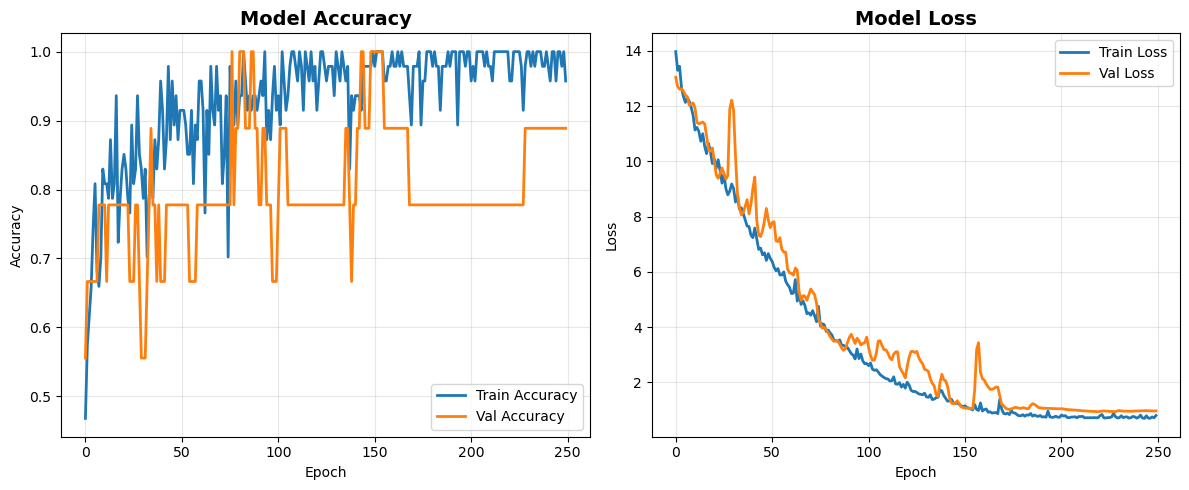

In [20]:
# =================================
# Cell 11: Plot Training History
# =================================

print("\nPlotting training history...")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [26]:
# ============================================================================
# Cell 12: Evaluate on Test Set (FIXED)
# ============================================================================
from tensorflow.keras.metrics import Precision, Recall

print("\nRe-compiling model to include all metrics...")
# We re-compile to ensure 'evaluate' returns exactly what we need.
# This does NOT reset the weights you just spent hours training.
model.compile(
    optimizer='adam', # Optimizer doesn't matter for evaluation
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

print("Evaluating on test set...")
test_generator.reset()

# Now it will return exactly 4 values
test_loss, test_acc, test_precision, test_recall = model.evaluate(test_generator)

# Safe calculation for F1 Score
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-7)

print("\n" + "=" * 70)
print("Mobile-NET FINAL TEST RESULTS")
print("=" * 70)
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")
print("=" * 70)


Re-compiling model to include all metrics...
Evaluating on test set...
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 1.0000 - loss: 0.0155 - precision: 1.0000 - recall: 1.0000

Mobile-NET FINAL TEST RESULTS
Test Loss:      0.0155
Test Accuracy:  1.0000 (100.00%)
Test Precision: 1.0000
Test Recall:    1.0000
Test F1-Score:  1.0000


In [28]:
# Test on validation set (more images)
print("VALIDATION SET PERFORMANCE:")
val_generator.reset()
val_loss, val_acc, val_prec, val_rec = model.evaluate(val_generator)

fold_results.append({
    "fold": fold + 1,
    "val_accuracy": val_acc,
    "val_precision": val_prec,
    "val_recall": val_rec
})
print(f"Val Accuracy: {val_acc:.4f}")
print(f"Val Precision: {val_prec:.4f}")
print(f"Val Recall: {val_rec:.4f}")

# Get predictions on validation set
val_preds = model.predict(val_generator, verbose=0)
val_pred_classes = (val_preds > 0.5).astype(int).flatten()
val_true = fold_val_df['label_encoded'].values

print("\nValidation Confusion Matrix:")

from sklearn.metrics import confusion_matrix
print(confusion_matrix(val_true, val_pred_classes))

VALIDATION SET PERFORMANCE:
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 1.0000 - loss: 0.0647 - precision: 1.0000 - recall: 1.0000
Val Accuracy: 1.0000
Val Precision: 1.0000
Val Recall: 1.0000

Validation Confusion Matrix:
[[5 0]
 [0 4]]


# Download Model

In [16]:
print("\nSaving model...")

# Save as .keras format (recommended)
model.save('cattle_disease.keras')
print("Model saved as: cattle_disease.keras")

# Save as .h5 format (legacy, still fine)
model.save('cattle_disease.h5')
print("Model also saved as: cattle_disease.h5")

# Save architecture to JSON
model_json = model.to_json()
with open("cattle_disease.json", "w") as json_file:
    json_file.write(model_json)
print("Model architecture saved as: cattle_disease.json")

# Save weights separately (filename must end with `.weights.h5`)
model.save_weights("cattle_disease.weights.h5")
print("Model weights saved as: cattle_disease.weights.h5")



Saving model...


Model saved as: cattle_disease.keras
Model also saved as: cattle_disease.h5
Model architecture saved as: cattle_disease.json
Model weights saved as: cattle_disease.weights.h5


# Demo

Loading MobileNet model...


Model loaded successfully.


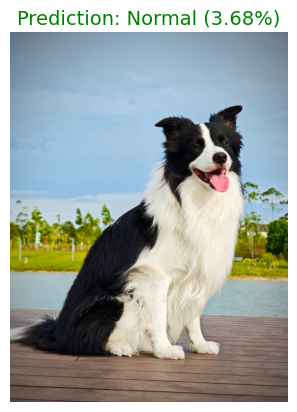


Prediction: Normal
Confidence: 3.68%


In [34]:
# ============================================
# MobileNet Demo: Predict Single Dog Image
# ============================================
import warnings
import logging
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from PIL import Image, ImageOps

# --- Silence warnings and logs ---
warnings.filterwarnings("ignore")
logging.getLogger("tensorflow").setLevel(logging.ERROR)

# --- Model paths ---
MODEL_PATH = r"cattle_disease.h5"
image_path = r"Dog Image 07-Nov-2025\Normal\collie1\IMG-20250526-WA0018.jpg"

# --- Label mapping ---
id2label = {1: "Abnormal", 0: "Normal"}

# --- Load model ---
print("Loading MobileNet model...")
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully.")

# --- Load image safely ---
img = Image.open(image_path)
img = ImageOps.exif_transpose(img).convert("RGB")
img = img.resize((224, 224))
img_array = np.expand_dims(np.array(img), axis=0)
img_array = preprocess_input(img_array)

# --- Predict ---
pred = model.predict(img_array, verbose=0)
confidence = float(np.max(pred) * 100)
pred_idx = int(np.argmax(pred))
label = id2label[pred_idx]

# --- Display result ---
plt.imshow(keras_image.load_img(image_path))
plt.axis("off")
plt.title(f"Prediction: {label} ({confidence:.2f}%)", fontsize=14, color="green")
plt.show()

print(f"\nPrediction: {label}")
print(f"Confidence: {confidence:.2f}%")


# GRAD-CAM Visualisation

Imports successful.
Loading model...
1. Checking image path: Dog Image 07-Nov-2025\Normal\From Evelyn\Luna\Luna- normal sit front view.jpeg
2. Preprocessing image...
3. Running prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
   Result: Abnormal (Conf: 0.9891)
4. Generating Heatmaps...
   - Processing layer: out_relu


C:\Users\ahmed\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


5. Displaying plot...


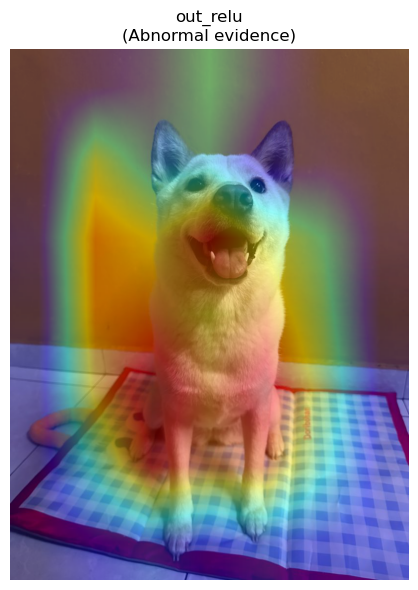

Done.


In [9]:
# ============================================
# DEBUG MODE: Grad-CAM Visualization
# ============================================
# 1. MAGIC COMMAND FOR JUPYTER (Critical!)
%matplotlib inline 

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
import cv2
import os

print("Imports successful.")

# -----------------------------
# Compute Grad-CAM
# -----------------------------
def compute_gradcam(model, img_array, layer_name, class_index=None):
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        score = predictions[0][0]
        
        if class_index == 1:
            loss = predictions[:, 0]
        else:
            loss = 1 - predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0)
    
    max_val = np.max(heatmap)
    if max_val == 0:
        return heatmap
    heatmap /= max_val
    return heatmap.numpy() if isinstance(heatmap, tf.Tensor) else heatmap

# -----------------------------
# Apply Heatmap
# -----------------------------
def apply_gradcam(img_path, heatmap, alpha=0.4, mask_path=None):
    img = keras_image.load_img(img_path)
    img = keras_image.img_to_array(img).astype("uint8")
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(heatmap_color, alpha, img_bgr, 1 - alpha, 0)
    
    # Mask logic (skipped if None)
    if mask_path and os.path.exists(mask_path):
        # ... (mask code as before) ...
        pass

    return cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

# -----------------------------
# Visualization Loop (With Debug Prints)
# -----------------------------
def visualize_gradcam_all_layers(model, img_path, layer_names, class_names=None, mask_path=None):
    print(f"1. Checking image path: {img_path}")
    if not os.path.exists(img_path):
        print("   ERROR: Image file not found! Check your path.")
        return

    print("2. Preprocessing image...")
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    print("3. Running prediction...")
    preds = model.predict(img_array)
    score = preds[0][0]
    
    if score > 0.5:
        top_class = 1; confidence = score
    else:
        top_class = 0; confidence = 1 - score
        
    label = class_names[top_class] if class_names else str(top_class)
    print(f"   Result: {label} (Conf: {confidence:.4f})")

    print("4. Generating Heatmaps...")
    plt.figure(figsize=(16, 6))
    for i, layer_name in enumerate(layer_names):
        print(f"   - Processing layer: {layer_name}")
        try:
            heatmap = compute_gradcam(model, img_array, layer_name, class_index=top_class)
            result = apply_gradcam(img_path, heatmap, alpha=0.4, mask_path=mask_path)
            
            plt.subplot(1, len(layer_names), i + 1)
            plt.imshow(result)
            plt.title(f"{layer_name}\n({label} evidence)")
            plt.axis("off")
        except Exception as e:
            print(f"   ERROR in layer {layer_name}: {e}")
            
    print("5. Displaying plot...")
    plt.tight_layout()
    plt.show()
    print("Done.")

# -----------------------------
# RUN
# -----------------------------
# Verify paths before running
MODEL_PATH = "Final_Dog_Posture_Model.keras" 
# CRITICAL: Verify this path matches exactly where your file is
# Change this path to an Abnormal image
IMAGE_PATH = r"Dog Image 07-Nov-2025\Normal\From Evelyn\Luna\Luna- normal sit front view.jpeg"

if 'model' not in locals():
    print("Loading model...")
    model = tf.keras.models.load_model(MODEL_PATH)

visualize_gradcam_all_layers(
    model, 
    IMAGE_PATH, 
    layer_names=["out_relu"], # Try just one layer first
    class_names=["Normal", "Abnormal"]
)

In [ ]:
// Function assumes you are passing an array of 4 HTML <img> elements
async function diagnoseDogPosture(imageElements) {
    if (imageElements.length !== 4) {
        console.error("Exactly 4 images are required!");
        return;
    }

    console.log("Loading model...");
    // Update this path to wherever you put the web_model folder in your app
    const model = await tf.loadLayersModel('./web_model/model.json'); 
    
    let redFlags = 0;
    let individualScores = [];

    console.log("Analyzing images...");
    for (let i = 0; i < imageElements.length; i++) {
        // 1. Convert image to Tensor & Preprocess exactly like MobileNetV2 expects
        const tensor = tf.tidy(() => {
            let imgTensor = tf.browser.fromPixels(imageElements[i]);
            // Resize to 224x224
            let resized = tf.image.resizeBilinear(imgTensor, [224, 224]);
            // MobileNetV2 preprocessing: scale pixels from [0, 255] to [-1, 1]
            let normalized = resized.toFloat().div(tf.scalar(127.5)).sub(tf.scalar(1.0));
            // Add batch dimension: [1, 224, 224, 3]
            return normalized.expandDims(0); 
        });

        // 2. Run the prediction
        const prediction = await model.predict(tensor).data();
        const score = prediction[0]; // A number between 0 (Normal) and 1 (Abnormal)
        individualScores.push(score);

        // 3. Check threshold
        if (score >= 0.5) {
            redFlags += 1;
        }

        // 4. CRITICAL: Clean up memory so the browser doesn't crash
        tf.dispose(tensor); 
    }

    // 5. The Ensemble Final Decision
    const confidence = (redFlags / 4) * 100;
    const diagnosis = redFlags >= 2 ? "Abnormal" : "Normal";

    console.log(`Scores: ${individualScores}`);
    console.log(`Red Flags: ${redFlags}/4`);
    console.log(`Final Diagnosis: ${diagnosis} (${confidence}% Confidence)`);

    return {
        diagnosis: diagnosis,
        confidence: confidence,
        redFlags: redFlags
    };
}